
# 09 — Embedding definitivi 10 s e baseline DN4

Configurazione fissata sulla base dei notebook 07 e 08:

- finestre da **10 s**;
- `patient_speech_ratio >= 0.30`;
- `openai/whisper-small`;
- pooling **VALID-ONLY**;
- aggregazione media degli embedding **per paziente**;
- classificazione `DN4 < 4` vs `DN4 >= 4`;
- Logistic Regression con Stratified 5-Fold Cross-Validation a livello paziente.

La durata e la soglia vengono fissate **prima** della classificazione, così da non
sceglierle in funzione delle prestazioni del modello.


In [1]:

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import soundfile as sf
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

PROJECT_DIR = Path.cwd()

if not (PROJECT_DIR / "risultati").exists():
    fallback = Path(r"C:\Users\acer\Desktop\ProgettoTesi")
    if fallback.exists():
        PROJECT_DIR = fallback

SEGMENT_DIR = PROJECT_DIR / "risultati" / "segmentazione_finestre"
METADATA_CSV = SEGMENT_DIR / "metadata_tutte_le_finestre_con_dn4.csv"

OUTPUT_DIR = PROJECT_DIR / "risultati" / "classificazione_dn4_10s_30"
FIGURE_DIR = OUTPUT_DIR / "figure"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "openai/whisper-small"
TARGET_SR = 16_000
WINDOW_SIZE = 10
MIN_PATIENT_RATIO = 0.30
RANDOM_STATE = 42

BATCH_SIZE_GPU = 8
BATCH_SIZE_CPU = 2
CHECKPOINT_EVERY = 10
FORCE_RECOMPUTE = False

print("PROJECT_DIR:", PROJECT_DIR)
print("METADATA_CSV:", METADATA_CSV)
print("METADATA_CSV esiste:", METADATA_CSV.exists())
print("OUTPUT_DIR:", OUTPUT_DIR)

if not METADATA_CSV.exists():
    raise FileNotFoundError(
        f"File non trovato: {METADATA_CSV}\n"
        "Eseguire prima il notebook 07."
    )


PROJECT_DIR: c:\Users\acer\Desktop\ProgettoTesi
METADATA_CSV: c:\Users\acer\Desktop\ProgettoTesi\risultati\segmentazione_finestre\metadata_tutte_le_finestre_con_dn4.csv
METADATA_CSV esiste: True
OUTPUT_DIR: c:\Users\acer\Desktop\ProgettoTesi\risultati\classificazione_dn4_10s_30


## 1. Selezione definitiva delle clip

In [2]:

metadata_all = pd.read_csv(METADATA_CSV)

required = {
    "clip_id",
    "audio_path",
    "recording_id",
    "patient_id",
    "window_size_seconds",
    "patient_speech_ratio",
    "dn4_score",
    "patient_label",
}

missing = required - set(metadata_all.columns)
if missing:
    raise ValueError(f"Colonne mancanti: {sorted(missing)}")

for col in [
    "patient_id",
    "window_size_seconds",
    "patient_speech_ratio",
    "dn4_score",
    "patient_label",
]:
    metadata_all[col] = pd.to_numeric(
        metadata_all[col],
        errors="coerce",
    )

clips = metadata_all[
    (metadata_all["window_size_seconds"] == WINDOW_SIZE)
    & (metadata_all["patient_speech_ratio"] >= MIN_PATIENT_RATIO)
].copy()

clips_labeled = clips[
    clips["patient_label"].notna()
].copy()

clips_labeled["audio_path"] = clips_labeled["audio_path"].astype(str)
clips_labeled["file_esistente"] = clips_labeled["audio_path"].apply(
    lambda x: Path(x).exists()
)

missing_audio = clips_labeled[~clips_labeled["file_esistente"]]

print("Clip 10 s con ratio >= 30%:", len(clips))
print("Pazienti complessivi:", clips["patient_id"].nunique())
print("Clip con DN4 disponibile:", len(clips_labeled))
print("Pazienti con DN4 disponibile:", clips_labeled["patient_id"].nunique())
print("File audio mancanti:", len(missing_audio))

display(
    clips_labeled.groupby("patient_label")
    .agg(
        pazienti=("patient_id", "nunique"),
        clip=("clip_id", "size"),
        dn4_medio=("dn4_score", "mean"),
    )
    .rename(index={0.0: "DN4 < 4", 1.0: "DN4 >= 4"})
)

if not missing_audio.empty:
    display(
        missing_audio[
            ["clip_id", "recording_id", "audio_path"]
        ].head(20)
    )
    raise FileNotFoundError("Alcuni file audio non esistono.")


Clip 10 s con ratio >= 30%: 1543
Pazienti complessivi: 90
Clip con DN4 disponibile: 1543
Pazienti con DN4 disponibile: 90
File audio mancanti: 0


,pazienti,clip,dn4_medio
patient_label,,,
DN4 < 4,44,674,1.329377
DN4 >= 4,46,869,5.817031


## 2. Controllo delle registrazioni multiple

In [3]:

registrazioni_per_paziente = (
    clips_labeled.groupby("patient_id")["recording_id"].nunique()
)

ripetuti = registrazioni_per_paziente[
    registrazioni_per_paziente > 1
]

print("Pazienti con più registrazioni:", len(ripetuti))

if len(ripetuti):
    display(
        clips_labeled[
            clips_labeled["patient_id"].isin(ripetuti.index)
        ]
        .groupby("patient_id")
        .agg(
            registrazioni=(
                "recording_id",
                lambda x: " | ".join(sorted(set(x.astype(str)))),
            ),
            numero_clip=("clip_id", "size"),
            dn4_score=("dn4_score", "first"),
            patient_label=("patient_label", "first"),
        )
        .reset_index()
    )


Pazienti con più registrazioni: 1


,patient_id,registrazioni,numero_clip,dn4_score,patient_label
0,16,ID16.StudioRuggi | ID16.StudioRuggi(1),12,6.0,1.0


## 3. Caricamento Whisper-small

In [4]:

import torch
import torch.nn.functional as F

from transformers import WhisperFeatureExtractor, WhisperModel

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = BATCH_SIZE_GPU if DEVICE == "cuda" else BATCH_SIZE_CPU

print("DEVICE:", DEVICE)
print("BATCH_SIZE:", BATCH_SIZE)

feature_extractor = WhisperFeatureExtractor.from_pretrained(
    MODEL_NAME,
    return_attention_mask=True,
)

model = WhisperModel.from_pretrained(MODEL_NAME)
model = model.to(DEVICE)
model.eval()

EMBEDDING_DIM = int(model.config.d_model)

print("Modello:", MODEL_NAME)
print("Embedding dim:", EMBEDDING_DIM)
print("Chunk length:", feature_extractor.chunk_length, "s")


DEVICE: cpu
BATCH_SIZE: 2


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Modello: openai/whisper-small
Embedding dim: 768
Chunk length: 30 s


## 4. Funzioni VALID-ONLY

In [5]:

def carica_audio(percorso):
    audio, sample_rate = sf.read(
        percorso,
        dtype="float32",
        always_2d=True,
    )

    audio = audio.mean(axis=1)

    if sample_rate != TARGET_SR:
        raise ValueError(
            f"{percorso}: sample rate {sample_rate}, atteso {TARGET_SR}."
        )

    return audio


def resize_mask_to_hidden(attention_mask, hidden_states):
    mask = attention_mask.float().unsqueeze(1)

    mask = F.interpolate(
        mask,
        size=hidden_states.shape[1],
        mode="nearest",
    ).squeeze(1)

    return mask.to(hidden_states.device)


def valid_only_mean_pool(hidden_states, attention_mask):
    hidden_mask = resize_mask_to_hidden(
        attention_mask,
        hidden_states,
    )

    denominatore = (
        hidden_mask.sum(dim=1, keepdim=True).clamp(min=1.0)
    )

    pooled = (
        hidden_states * hidden_mask.unsqueeze(-1)
    ).sum(dim=1) / denominatore

    return pooled


## 5. Estrazione definitiva degli embedding delle clip

In [6]:

CHECKPOINT_NPZ = OUTPUT_DIR / "checkpoint_embedding_clip.npz"
FINAL_CLIP_NPZ = OUTPUT_DIR / "embedding_clip_10s_30_valid_only.npz"
FINAL_CLIP_METADATA = OUTPUT_DIR / "metadata_clip_embedding.csv"

embedding_by_id = {}

if CHECKPOINT_NPZ.exists() and not FORCE_RECOMPUTE:
    checkpoint = np.load(
        CHECKPOINT_NPZ,
        allow_pickle=True,
    )

    ids = checkpoint["clip_id"].astype(str)
    embeddings = checkpoint["embeddings"]

    for clip_id, emb in zip(ids, embeddings):
        embedding_by_id[str(clip_id)] = np.asarray(
            emb,
            dtype=np.float32,
        )

    print("Embedding caricati dal checkpoint:", len(embedding_by_id))


clips_ordered = (
    clips_labeled
    .sort_values(["patient_id", "recording_id", "clip_id"])
    .reset_index(drop=True)
)

to_compute = clips_ordered[
    ~clips_ordered["clip_id"].astype(str).isin(embedding_by_id.keys())
].copy()

print("Clip totali:", len(clips_ordered))
print("Già disponibili:", len(clips_ordered) - len(to_compute))
print("Da elaborare:", len(to_compute))


def save_checkpoint():
    if not embedding_by_id:
        return

    ids = list(embedding_by_id.keys())
    matrix = np.vstack([embedding_by_id[i] for i in ids])

    np.savez_compressed(
        CHECKPOINT_NPZ,
        clip_id=np.array(ids, dtype=object),
        embeddings=matrix.astype(np.float32),
    )


for batch_number, start in enumerate(
    range(0, len(to_compute), BATCH_SIZE),
    start=1,
):
    end = min(start + BATCH_SIZE, len(to_compute))
    batch_df = to_compute.iloc[start:end]

    audios = [
        carica_audio(path)
        for path in batch_df["audio_path"]
    ]

    inputs = feature_extractor(
        audios,
        sampling_rate=TARGET_SR,
        return_tensors="pt",
        padding="max_length",
        return_attention_mask=True,
    )

    input_features = inputs.input_features.to(DEVICE)
    attention_mask = inputs.attention_mask.to(DEVICE)

    with torch.inference_mode():
        encoder_outputs = model.encoder(
            input_features,
            return_dict=True,
        )

        hidden_states = encoder_outputs.last_hidden_state

        pooled = valid_only_mean_pool(
            hidden_states,
            attention_mask,
        )

    batch_embeddings = (
        pooled.detach().cpu().numpy().astype(np.float32)
    )

    for clip_id, emb in zip(
        batch_df["clip_id"].astype(str),
        batch_embeddings,
    ):
        embedding_by_id[clip_id] = emb

    print(
        f"\rEmbedding disponibili: "
        f"{len(embedding_by_id)}/{len(clips_ordered)}",
        end="",
    )

    if batch_number % CHECKPOINT_EVERY == 0:
        save_checkpoint()

print()
save_checkpoint()

missing_embeddings = [
    str(clip_id)
    for clip_id in clips_ordered["clip_id"]
    if str(clip_id) not in embedding_by_id
]

if missing_embeddings:
    raise RuntimeError(
        f"Mancano embedding per {len(missing_embeddings)} clip."
    )

clip_embeddings = np.vstack([
    embedding_by_id[str(clip_id)]
    for clip_id in clips_ordered["clip_id"]
]).astype(np.float32)

np.savez_compressed(
    FINAL_CLIP_NPZ,
    clip_id=clips_ordered["clip_id"].astype(str).to_numpy(dtype=object),
    embeddings=clip_embeddings,
)

clips_ordered[
    [
        "clip_id",
        "patient_id",
        "recording_id",
        "dn4_score",
        "patient_label",
        "patient_speech_ratio",
        "audio_path",
    ]
].to_csv(
    FINAL_CLIP_METADATA,
    index=False,
)

print("Forma embedding clip:", clip_embeddings.shape)
print("NPZ:", FINAL_CLIP_NPZ)


Embedding caricati dal checkpoint: 1543
Clip totali: 1543
Già disponibili: 1543
Da elaborare: 0

Forma embedding clip: (1543, 768)
NPZ: c:\Users\acer\Desktop\ProgettoTesi\risultati\classificazione_dn4_10s_30\embedding_clip_10s_30_valid_only.npz


## 6. Aggregazione a livello paziente

In [7]:

from sklearn.preprocessing import normalize

patient_rows = []
patient_embeddings = []

for patient_id, idx_list in clips_ordered.groupby("patient_id").groups.items():
    idx = np.asarray(list(idx_list), dtype=int)

    patient_df = clips_ordered.iloc[idx]
    patient_emb = clip_embeddings[idx].mean(axis=0)

    labels = patient_df["patient_label"].dropna().unique()
    scores = patient_df["dn4_score"].dropna().unique()

    if len(labels) != 1:
        raise ValueError(
            f"Patient {patient_id}: etichette incoerenti {labels}"
        )

    if len(scores) != 1:
        raise ValueError(
            f"Patient {patient_id}: DN4 incoerenti {scores}"
        )

    patient_embeddings.append(patient_emb)

    patient_rows.append({
        "patient_id": int(patient_id),
        "dn4_score": float(scores[0]),
        "patient_label": int(labels[0]),
        "numero_clip": len(idx),
        "numero_registrazioni": patient_df["recording_id"].nunique(),
        "registrazioni": " | ".join(
            sorted(set(patient_df["recording_id"].astype(str)))
        ),
        "patient_ratio_medio": float(
            patient_df["patient_speech_ratio"].mean()
        ),
    })


patient_metadata = pd.DataFrame(patient_rows)

patient_embeddings = np.vstack(
    patient_embeddings
).astype(np.float32)

patient_embeddings = normalize(
    patient_embeddings,
    norm="l2",
).astype(np.float32)

PATIENT_NPZ = OUTPUT_DIR / "embedding_paziente_10s_30_valid_only.npz"
PATIENT_CSV = OUTPUT_DIR / "metadata_pazienti_classificazione.csv"

np.savez_compressed(
    PATIENT_NPZ,
    patient_id=patient_metadata["patient_id"].to_numpy(),
    embeddings=patient_embeddings,
)

patient_metadata.to_csv(PATIENT_CSV, index=False)

print("Pazienti:", len(patient_metadata))
print("Forma embedding paziente:", patient_embeddings.shape)

display(
    patient_metadata["patient_label"]
    .value_counts()
    .sort_index()
    .rename(index={0: "DN4 < 4", 1: "DN4 >= 4"})
    .rename("pazienti")
    .to_frame()
)

display(
    patient_metadata[
        ["numero_clip", "numero_registrazioni", "patient_ratio_medio"]
    ].describe()
)


Pazienti: 90
Forma embedding paziente: (90, 768)


,pazienti
patient_label,
DN4 < 4,44
DN4 >= 4,46


,numero_clip,numero_registrazioni,patient_ratio_medio
count,90.000000,90.000000,90.000000
mean,17.144444,1.011111,0.536842
std,13.279672,0.105409,0.102465
min,1.000000,1.000000,0.306000
25%,7.000000,1.000000,0.447308
50%,14.000000,1.000000,0.532714
75%,23.000000,1.000000,0.608987
max,73.000000,2.000000,0.783003


## 7. Logistic Regression — Stratified 5-Fold CV

In [8]:

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    auc,
)

X = patient_embeddings
y = patient_metadata["patient_label"].astype(int).to_numpy()

class_counts = pd.Series(y).value_counts().sort_index()

print("Distribuzione classi:")
display(class_counts.rename("pazienti").to_frame())

N_SPLITS = min(5, int(class_counts.min()))

if N_SPLITS < 2:
    raise RuntimeError("Numero di pazienti insufficiente per la CV.")

cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            penalty="l2",
            C=1.0,
            solver="liblinear",
            class_weight="balanced",
            max_iter=5000,
            random_state=RANDOM_STATE,
        ),
    ),
])

oof_probability = np.full(len(y), np.nan, dtype=float)
oof_prediction = np.full(len(y), -1, dtype=int)

fold_rows = []

for fold, (train_idx, test_idx) in enumerate(
    cv.split(X, y),
    start=1,
):
    pipeline.fit(
        X[train_idx],
        y[train_idx],
    )

    prob = pipeline.predict_proba(
        X[test_idx]
    )[:, 1]

    pred = (prob >= 0.5).astype(int)

    oof_probability[test_idx] = prob
    oof_prediction[test_idx] = pred

    tn, fp, fn, tp = confusion_matrix(
        y[test_idx],
        pred,
        labels=[0, 1],
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    fold_rows.append({
        "fold": fold,
        "n_train": len(train_idx),
        "n_test": len(test_idx),
        "accuracy": accuracy_score(y[test_idx], pred),
        "balanced_accuracy": balanced_accuracy_score(
            y[test_idx],
            pred,
        ),
        "precision": precision_score(
            y[test_idx],
            pred,
            zero_division=0,
        ),
        "sensitivity_recall": recall_score(
            y[test_idx],
            pred,
            zero_division=0,
        ),
        "specificity": specificity,
        "f1": f1_score(
            y[test_idx],
            pred,
            zero_division=0,
        ),
        "roc_auc": roc_auc_score(
            y[test_idx],
            prob,
        ),
    })

fold_metrics = pd.DataFrame(fold_rows)

display(fold_metrics.round(4))


Distribuzione classi:


,pazienti
0,44
1,46


,fold,n_train,n_test,accuracy,balanced_accuracy,precision,sensitivity_recall,specificity,f1,roc_auc
0,1,72,18,0.4444,0.4444,0.4444,0.4444,0.4444,0.4444,0.4938
1,2,72,18,0.5556,0.5556,0.5385,0.7778,0.3333,0.6364,0.7160
2,3,72,18,0.5556,0.5556,0.5556,0.5556,0.5556,0.5556,0.6543
3,4,72,18,0.5000,0.5000,0.5000,0.4444,0.5556,0.4706,0.5309
4,5,72,18,0.3889,0.3875,0.4444,0.4000,0.3750,0.4211,0.4375


## 8. Metriche complessive out-of-fold

In [9]:

tn, fp, fn, tp = confusion_matrix(
    y,
    oof_prediction,
    labels=[0, 1],
).ravel()

specificity_oof = tn / (tn + fp)

oof_metrics = pd.DataFrame([{
    "n_pazienti": len(y),
    "accuracy": accuracy_score(y, oof_prediction),
    "balanced_accuracy": balanced_accuracy_score(
        y,
        oof_prediction,
    ),
    "precision": precision_score(
        y,
        oof_prediction,
        zero_division=0,
    ),
    "sensitivity_recall": recall_score(
        y,
        oof_prediction,
        zero_division=0,
    ),
    "specificity": specificity_oof,
    "f1": f1_score(
        y,
        oof_prediction,
        zero_division=0,
    ),
    "roc_auc": roc_auc_score(
        y,
        oof_probability,
    ),
}])

display(oof_metrics.round(4))

metric_columns = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "sensitivity_recall",
    "specificity",
    "f1",
    "roc_auc",
]

cv_summary = pd.DataFrame([
    {
        "metrica": metric,
        "media_fold": fold_metrics[metric].mean(),
        "std_fold": fold_metrics[metric].std(ddof=1),
    }
    for metric in metric_columns
])

display(cv_summary.round(4))


,n_pazienti,accuracy,balanced_accuracy,precision,sensitivity_recall,specificity,f1,roc_auc
0,90,0.4889,0.4881,0.5,0.5217,0.4545,0.5106,0.54


,metrica,media_fold,std_fold
0,accuracy,0.4889,0.0724
1,balanced_accuracy,0.4886,0.0729
2,precision,0.4966,0.0517
3,sensitivity_recall,0.5244,0.1528
4,specificity,0.4528,0.1019
5,f1,0.5056,0.0890
6,roc_auc,0.5665,0.1154


## 9. Confusion matrix e ROC out-of-fold

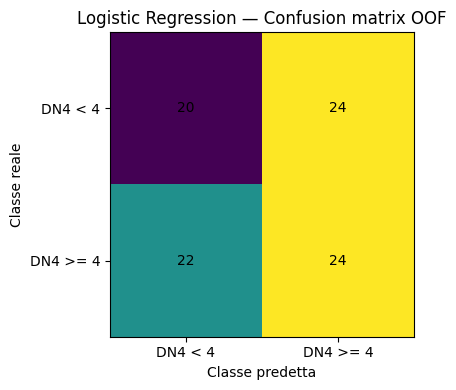

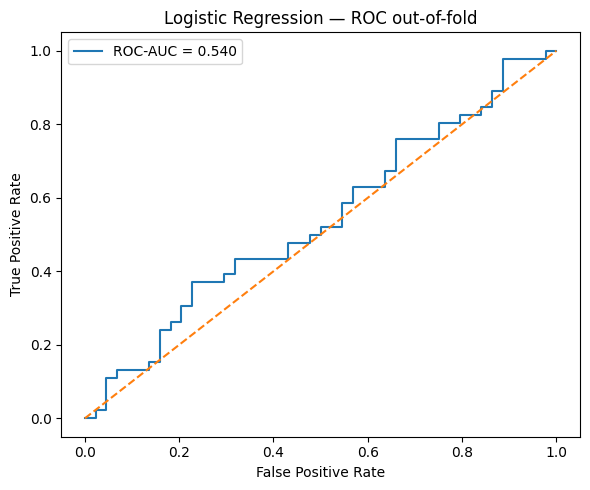

In [11]:

cm = confusion_matrix(
    y,
    oof_prediction,
    labels=[0, 1],
)

plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("Logistic Regression — Confusion matrix OOF")
plt.xlabel("Classe predetta")
plt.ylabel("Classe reale")
plt.xticks([0, 1], ["DN4 < 4", "DN4 >= 4"])
plt.yticks([0, 1], ["DN4 < 4", "DN4 >= 4"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
        )

plt.tight_layout()

CM_PNG = FIGURE_DIR / "confusion_matrix_oof.png"
plt.savefig(CM_PNG, dpi=200)
plt.savefig("img/Confusion-matrix oof.png", dpi=300, bbox_inches="tight")
plt.show()


fpr, tpr, _ = roc_curve(
    y,
    oof_probability,
)

roc_auc_value = auc(
    fpr,
    tpr,
)

plt.figure(figsize=(6, 5))
plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc_value:.3f}",
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression — ROC out-of-fold")
plt.legend()
plt.tight_layout()

ROC_PNG = FIGURE_DIR / "roc_oof.png"
plt.savefig(ROC_PNG, dpi=200)
plt.savefig("img/Logistic Regression-Confusion matrix OOF.png", dpi=300, bbox_inches="tight")
plt.show()


## 10. Salvataggio risultati

In [22]:

predictions_df = patient_metadata.copy()

predictions_df["probabilita_dn4_ge_4_oof"] = oof_probability
predictions_df["classe_predetta_oof"] = oof_prediction
predictions_df["corretto"] = (
    predictions_df["patient_label"].astype(int)
    == predictions_df["classe_predetta_oof"].astype(int)
)

PREDICTIONS_CSV = OUTPUT_DIR / "predizioni_oof_per_paziente.csv"
FOLD_METRICS_CSV = OUTPUT_DIR / "metriche_per_fold.csv"
OOF_METRICS_CSV = OUTPUT_DIR / "metriche_oof.csv"
CV_SUMMARY_CSV = OUTPUT_DIR / "riepilogo_cv.csv"
CONFIG_JSON = OUTPUT_DIR / "config_classificazione.json"

predictions_df.to_csv(PREDICTIONS_CSV, index=False)
fold_metrics.to_csv(FOLD_METRICS_CSV, index=False)
oof_metrics.to_csv(OOF_METRICS_CSV, index=False)
cv_summary.to_csv(CV_SUMMARY_CSV, index=False)

config = {
    "model_name": MODEL_NAME,
    "window_size_seconds": WINDOW_SIZE,
    "min_patient_speech_ratio": MIN_PATIENT_RATIO,
    "pooling": "valid_only_mean",
    "aggregation": "mean_per_patient",
    "classifier": "LogisticRegression L2 class_weight=balanced",
    "cross_validation": f"StratifiedKFold({N_SPLITS})",
    "random_state": RANDOM_STATE,
    "n_clip": int(len(clips_ordered)),
    "n_patients": int(len(patient_metadata)),
    "embedding_dim": int(patient_embeddings.shape[1]),
}

with open(CONFIG_JSON, "w", encoding="utf-8") as f:
    json.dump(
        config,
        f,
        indent=2,
        ensure_ascii=False,
    )

print("Risultati salvati in:", OUTPUT_DIR)

for path in [
    FINAL_CLIP_NPZ,
    FINAL_CLIP_METADATA,
    PATIENT_NPZ,
    PATIENT_CSV,
    FOLD_METRICS_CSV,
    OOF_METRICS_CSV,
    CV_SUMMARY_CSV,
    PREDICTIONS_CSV,
    CONFIG_JSON,
    CM_PNG,
    ROC_PNG,
]:
    print(" -", path)


Risultati salvati in: c:\Users\acer\Desktop\ProgettoTesi\risultati\classificazione_dn4_10s_30
 - c:\Users\acer\Desktop\ProgettoTesi\risultati\classificazione_dn4_10s_30\embedding_clip_10s_30_valid_only.npz
 - c:\Users\acer\Desktop\ProgettoTesi\risultati\classificazione_dn4_10s_30\metadata_clip_embedding.csv
 - c:\Users\acer\Desktop\ProgettoTesi\risultati\classificazione_dn4_10s_30\embedding_paziente_10s_30_valid_only.npz
 - c:\Users\acer\Desktop\ProgettoTesi\risultati\classificazione_dn4_10s_30\metadata_pazienti_classificazione.csv
 - c:\Users\acer\Desktop\ProgettoTesi\risultati\classificazione_dn4_10s_30\metriche_per_fold.csv
 - c:\Users\acer\Desktop\ProgettoTesi\risultati\classificazione_dn4_10s_30\metriche_oof.csv
 - c:\Users\acer\Desktop\ProgettoTesi\risultati\classificazione_dn4_10s_30\riepilogo_cv.csv
 - c:\Users\acer\Desktop\ProgettoTesi\risultati\classificazione_dn4_10s_30\predizioni_oof_per_paziente.csv
 - c:\Users\acer\Desktop\ProgettoTesi\risultati\classificazione_dn4_10s_30


## 11. Permutation test sulla ROC-AUC

Questo controllo verifica se la ROC-AUC osservata è realmente superiore a ciò
che si potrebbe ottenere casualmente mescolando le etichette DN4 tra i pazienti.

La configurazione resta invariata: 10 s, soglia 30%, pooling VALID-ONLY,
aggregazione per paziente, Logistic Regression e stessi fold della baseline.


In [23]:

from sklearn.base import clone

N_PERMUTATIONS = 1000
PERMUTATION_RANDOM_STATE = 42

rng = np.random.default_rng(PERMUTATION_RANDOM_STATE)

fixed_splits = list(cv.split(X, y))

observed_auc = roc_auc_score(
    y,
    oof_probability,
)

permuted_aucs = []

print(
    "ROC-AUC osservata:",
    round(float(observed_auc), 4),
)

for permutation_index in range(N_PERMUTATIONS):
    y_perm = rng.permutation(y)

    perm_oof_probability = np.full(
        len(y_perm),
        np.nan,
        dtype=float,
    )

    valid_permutation = True

    for train_idx, test_idx in fixed_splits:
        y_train_perm = y_perm[train_idx]

        if np.unique(y_train_perm).size < 2:
            valid_permutation = False
            break

        model_perm = clone(pipeline)

        model_perm.fit(
            X[train_idx],
            y_train_perm,
        )

        perm_oof_probability[test_idx] = (
            model_perm
            .predict_proba(
                X[test_idx]
            )[:, 1]
        )

    if (
        not valid_permutation
        or np.isnan(perm_oof_probability).any()
        or np.unique(y_perm).size < 2
    ):
        continue

    auc_perm = roc_auc_score(
        y_perm,
        perm_oof_probability,
    )

    permuted_aucs.append(auc_perm)

    if (permutation_index + 1) % 100 == 0:
        print(
            f"Permutazioni completate: "
            f"{permutation_index + 1}/{N_PERMUTATIONS}"
        )

permuted_aucs = np.asarray(
    permuted_aucs,
    dtype=float,
)

if len(permuted_aucs) == 0:
    raise RuntimeError(
        "Nessuna permutazione valida."
    )

p_value = (
    1
    + np.sum(permuted_aucs >= observed_auc)
) / (
    1
    + len(permuted_aucs)
)

permutation_summary = pd.DataFrame([
    {
        "auc_osservata": observed_auc,
        "n_permutazioni_valide": len(permuted_aucs),
        "auc_null_media": float(permuted_aucs.mean()),
        "auc_null_std": float(permuted_aucs.std(ddof=1)),
        "auc_null_95_percentile": float(
            np.quantile(permuted_aucs, 0.95)
        ),
        "p_value_permutation": float(p_value),
    }
])

display(
    permutation_summary.round(4)
)

if p_value < 0.05:
    print(
        "\nL'ROC-AUC osservata risulta superiore "
        "al caso al livello convenzionale del 5%."
    )
else:
    print(
        "\nNon emerge evidenza che l'ROC-AUC "
        "osservata sia superiore al caso "
        "al livello convenzionale del 5%."
    )


ROC-AUC osservata: 0.54
Permutazioni completate: 100/1000
Permutazioni completate: 200/1000
Permutazioni completate: 300/1000
Permutazioni completate: 400/1000
Permutazioni completate: 500/1000
Permutazioni completate: 600/1000
Permutazioni completate: 700/1000
Permutazioni completate: 800/1000
Permutazioni completate: 900/1000
Permutazioni completate: 1000/1000


,auc_osservata,n_permutazioni_valide,auc_null_media,auc_null_std,auc_null_95_percentile,p_value_permutation
0,0.54,1000,0.4987,0.0828,0.6311,0.3197



Non emerge evidenza che l'ROC-AUC osservata sia superiore al caso al livello convenzionale del 5%.


### Distribuzione nulla delle ROC-AUC

In [ ]:

plt.figure(figsize=(7, 5))

plt.hist(
    permuted_aucs,
    bins=30,
    alpha=0.8,
)

plt.axvline(
    observed_auc,
    linestyle="--",
    linewidth=2,
    label=f"AUC osservata = {observed_auc:.3f}",
)

plt.xlabel(
    "ROC-AUC con etichette permutate"
)

plt.ylabel(
    "Frequenza"
)

plt.title(
    "Permutation test — distribuzione nulla della ROC-AUC"
)

plt.legend()
plt.tight_layout()

PERMUTATION_PNG = (
    FIGURE_DIR
    / "permutation_test_auc.png"
)

plt.savefig(
    PERMUTATION_PNG,
    dpi=200,
)

plt.show()

print("Figura:", PERMUTATION_PNG)


### Salvataggio del permutation test

In [ ]:

PERMUTATION_SUMMARY_CSV = (
    OUTPUT_DIR
    / "permutation_test_auc_summary.csv"
)

PERMUTATION_VALUES_CSV = (
    OUTPUT_DIR
    / "permutation_test_auc_values.csv"
)

permutation_summary.to_csv(
    PERMUTATION_SUMMARY_CSV,
    index=False,
)

pd.DataFrame({
    "auc_permutata": permuted_aucs
}).to_csv(
    PERMUTATION_VALUES_CSV,
    index=False,
)

print(
    "Summary:",
    PERMUTATION_SUMMARY_CSV
)

print(
    "Valori permutati:",
    PERMUTATION_VALUES_CSV
)
